<a href="https://colab.research.google.com/github/sulthanalihsan/data-science-2026/blob/main/Pertemuan5_Muhamad_Sulthan_Al_Ihsan_250401020154.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pertemuan 5 — Dashboard Visualisasi Statis
**Nama  :** Muhammad Sulthan Al Ihsan
**NIM   :** 250401020154
**Dataset:** Tips (seaborn)
**Mata Kuliah:** Data Science —  S1 Informatika

## 1. Import Library dan Load Dataset

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Load dataset ──────────────────────────────────────────────
df = sns.load_dataset('tips')

# ── Global style ──────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='Set2')

print('Jumlah baris dan kolom:', df.shape)
print('\nTipe data setiap kolom:')
print(df.dtypes)
print('\nStatistik deskriptif:')
df.describe().round(2)

Jumlah baris dan kolom: (244, 7)

Tipe data setiap kolom:
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Statistik deskriptif:


,total_bill,tip,size
count,244.00,244.00,244.00
mean,19.79,3.00,2.57
std,8.90,1.38,0.95
min,3.07,1.00,1.00
25%,13.35,2.00,2.00
50%,17.80,2.90,2.00
75%,24.13,3.56,3.00
max,50.81,10.00,6.00


## 2. Grafik 1 — Bar Chart: Rata-rata Total Tagihan per Hari dan Jenis Kelamin

**What?**
Grafik batang ini menampilkan rata-rata total tagihan (USD) untuk setiap hari operasional
restoran (Kamis, Jumat, Sabtu, Minggu), dikelompokkan berdasarkan jenis kelamin pelanggan.
Nilai rata-rata berkisar antara $14.15 (perempuan, Jumat) hingga $21.89 (laki-laki, Minggu).

**So what?**
Pelanggan laki-laki secara konsisten memiliki rata-rata tagihan lebih tinggi dibandingkan
perempuan di semua hari, dengan selisih terbesar pada hari Jumat ($19.86 vs $14.15, selisih $5.71).
Hari Minggu mencatat nilai tertinggi untuk kedua kelompok, mengindikasikan perilaku
konsumsi yang lebih besar di akhir pekan.

**Now what?**
Restoran dapat merancang promosi paket makan khusus untuk pelanggan perempuan guna
meningkatkan nilai rata-rata transaksi, terutama di hari Jumat yang menunjukkan kesenjangan
paling besar. Perlu dieksplorasi lebih lanjut apakah perbedaan tagihan ini berkaitan dengan
pilihan menu atau ukuran kelompok yang berbeda antar gender.

/tmp/ipykernel_1618/3347425953.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_bill = df.groupby(['day', 'sex'])['total_bill'].mean().reset_index()


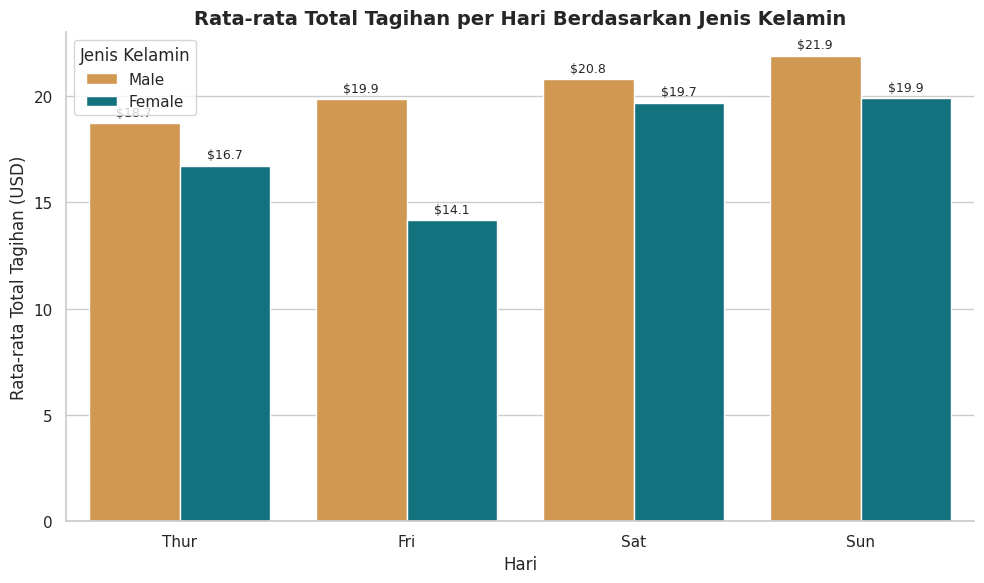

Grafik 1 tersimpan sebagai grafik1_bar_chart.png


In [8]:
day_order = ['Thur', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=(10, 6))

avg_bill = df.groupby(['day', 'sex'])['total_bill'].mean().reset_index()

sns.barplot(
    data=avg_bill,
    x='day', y='total_bill', hue='sex',
    order=day_order,
    palette=['#E69B3A', '#028090'],
    ax=ax
)

ax.set_title(
    'Rata-rata Total Tagihan per Hari Berdasarkan Jenis Kelamin',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('Hari')
ax.set_ylabel('Rata-rata Total Tagihan (USD)')
ax.legend(title='Jenis Kelamin')
ax.spines[['top', 'right']].set_visible(False)

# Tampilkan nilai di atas setiap bar
for container in ax.containers:
    ax.bar_label(container, fmt='$%.1f', padding=3, fontsize=9)

plt.tight_layout()
plt.savefig('grafik1_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik 1 tersimpan sebagai grafik1_bar_chart.png')

## 3. Grafik 2 — Histogram + KDE: Distribusi Total Tagihan per Status Merokok

**What?**
Grafik ini menampilkan distribusi total tagihan (USD) yang dibandingkan antara pelanggan
perokok (93 transaksi) dan bukan perokok (151 transaksi), disajikan dalam dua bentuk:
histogram dengan kurva KDE (kiri) dan kurva kepadatan penuh (kanan).
Kedua kelompok menunjukkan distribusi yang condong ke kanan (right-skewed).

**So what?**
Pelanggan perokok memiliki rata-rata tagihan sedikit lebih tinggi ($20.76) dibandingkan
bukan perokok ($19.19), namun median keduanya hampir serupa ($17.92 vs $17.59).
Perokok menunjukkan variabilitas lebih besar (std $9.83 vs $8.26), menandakan perilaku
belanja yang lebih beragam di antara kelompok tersebut.

**Now what?**
Perbedaan rata-rata tagihan antar kelompok tidak terlalu signifikan, sehingga strategi harga
atau menu tidak perlu dibedakan berdasarkan status merokok. Perlu diteliti lebih lanjut
apakah penataan area merokok dan non-merokok memengaruhi kepuasan pelanggan dan
besarnya tip yang diberikan.

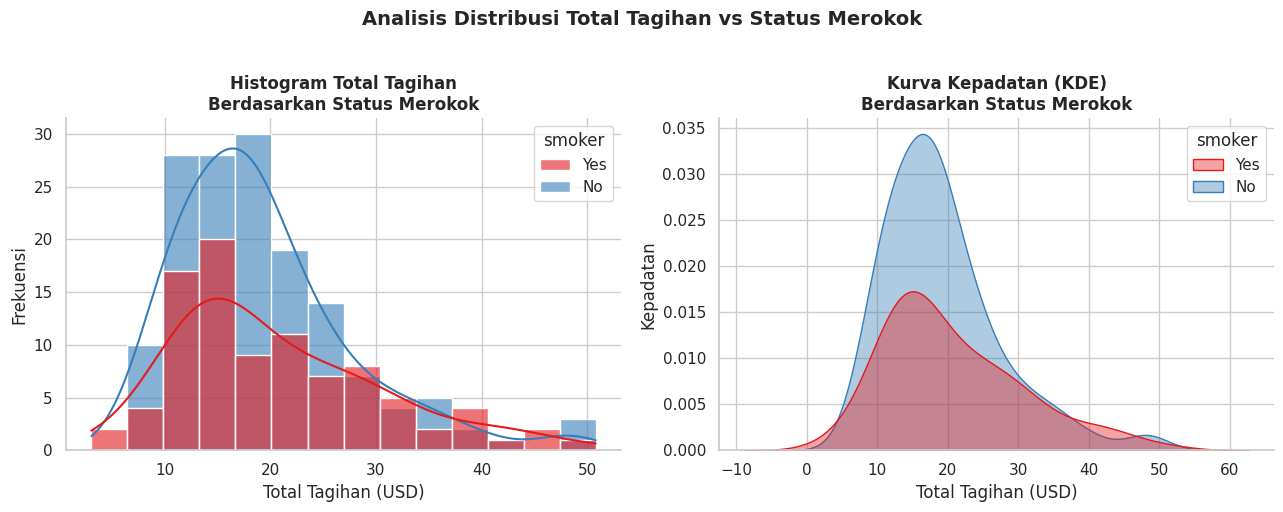

Grafik 2 tersimpan sebagai grafik2_histogram_kde.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Subplot kiri: Histogram + KDE ─────────────────────────────
sns.histplot(
    data=df, x='total_bill', hue='smoker',
    kde=True, palette='Set1', alpha=0.6, ax=axes[0]
)
axes[0].set_title(
    'Histogram Total Tagihan\nBerdasarkan Status Merokok',
    fontsize=12, fontweight='bold'
)
axes[0].set_xlabel('Total Tagihan (USD)')
axes[0].set_ylabel('Frekuensi')
axes[0].spines[['top', 'right']].set_visible(False)

# ── Subplot kanan: KDE (filled) ───────────────────────────────
sns.kdeplot(
    data=df, x='total_bill', hue='smoker',
    fill=True, palette='Set1', alpha=0.4, ax=axes[1]
)
axes[1].set_title(
    'Kurva Kepadatan (KDE)\nBerdasarkan Status Merokok',
    fontsize=12, fontweight='bold'
)
axes[1].set_xlabel('Total Tagihan (USD)')
axes[1].set_ylabel('Kepadatan')
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle(
    'Analisis Distribusi Total Tagihan vs Status Merokok',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('grafik2_histogram_kde.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik 2 tersimpan sebagai grafik2_histogram_kde.png')

## 4. Grafik 3 — Boxplot dan Violin Plot: Distribusi Tip per Hari

**What?**
Grafik ini memadukan boxplot (kiri) dan violin plot (kanan) untuk menampilkan distribusi
lengkap jumlah tip (USD) pada setiap hari operasional restoran. Boxplot merangkum statistik
utama (median, kuartil, dan outlier), sementara violin plot menampilkan bentuk distribusi
data secara penuh melalui estimasi kepadatan kernel (KDE).

**So what?**
Hari Minggu mencatat median tip tertinggi sebesar $3.15 dan rata-rata $3.26, sementara
Kamis memiliki median terendah sebesar $2.30. Hari Sabtu menunjukkan outlier ekstrem
hingga $10.00 yang jauh melampaui hari lainnya, sedangkan hari Jumat memiliki distribusi
paling kompak dengan nilai maksimum hanya $4.73.

**Now what?**
Kualitas pelayanan di hari Kamis perlu dievaluasi karena tip secara konsisten lebih rendah
dibandingkan hari-hari lainnya. Transaksi Sabtu dengan tip $10.00 layak diselidiki lebih
lanjut untuk mengidentifikasi faktor pendorong kepuasan pelanggan tertinggi dan menjadikannya
referensi standar pelayanan terbaik.

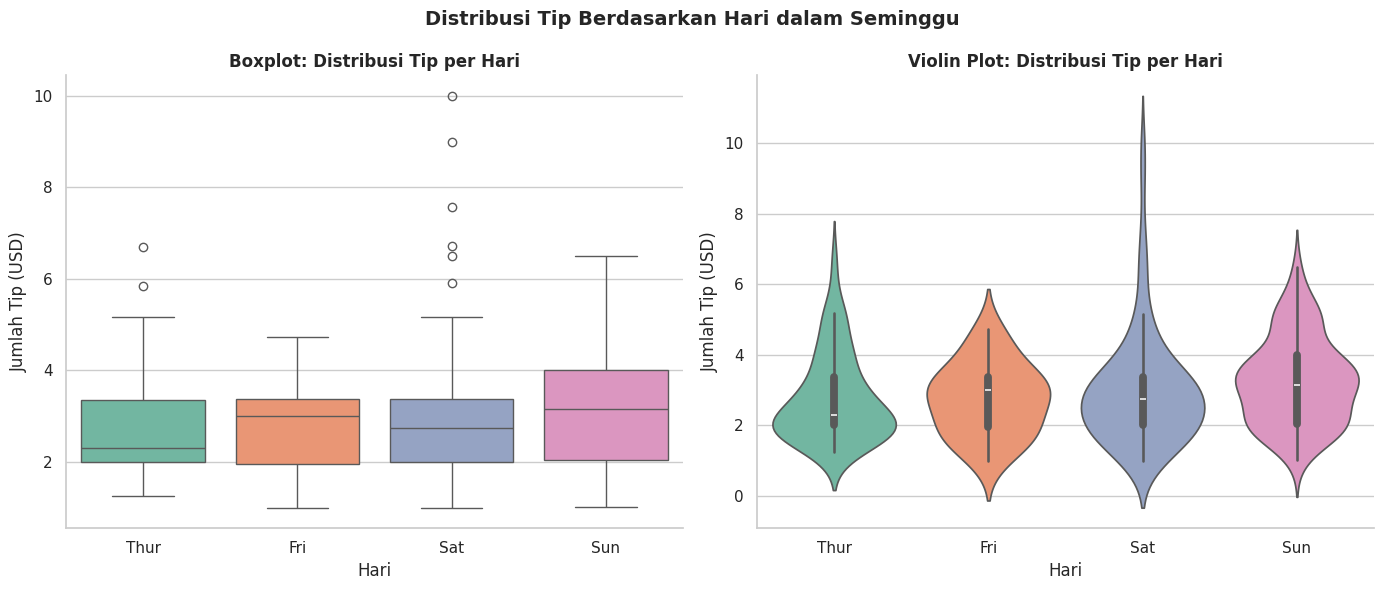

Grafik 3 tersimpan sebagai grafik3_boxplot_violin.png


In [10]:
day_order = ['Thur', 'Fri', 'Sat', 'Sun']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Subplot kiri: Boxplot ──────────────────────────────────────
sns.boxplot(
    data=df, x='day', y='tip',
    order=day_order, hue='day', legend=False,
    palette='Set2', ax=axes[0]
)
axes[0].set_title(
    'Boxplot: Distribusi Tip per Hari',
    fontsize=12, fontweight='bold'
)
axes[0].set_xlabel('Hari')
axes[0].set_ylabel('Jumlah Tip (USD)')
axes[0].spines[['top', 'right']].set_visible(False)

# ── Subplot kanan: Violin Plot ────────────────────────────────
sns.violinplot(
    data=df, x='day', y='tip',
    order=day_order, hue='day', legend=False,
    inner='box', palette='Set2', ax=axes[1]
)
axes[1].set_title(
    'Violin Plot: Distribusi Tip per Hari',
    fontsize=12, fontweight='bold'
)
axes[1].set_xlabel('Hari')
axes[1].set_ylabel('Jumlah Tip (USD)')
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle(
    'Distribusi Tip Berdasarkan Hari dalam Seminggu',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('grafik3_boxplot_violin.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik 3 tersimpan sebagai grafik3_boxplot_violin.png')

## 5. Grafik 4 — Scatter Plot: Hubungan Total Tagihan vs Tip

**What?**
Scatter plot ini menampilkan hubungan antara total tagihan (sumbu X) dan jumlah tip
(sumbu Y) dari 244 transaksi, dengan warna berbeda untuk setiap hari dan ukuran titik
yang merepresentasikan jumlah tamu dalam satu kelompok (1 hingga 6 orang).
Garis regresi putus-putus abu-abu menunjukkan tren keseluruhan hubungan kedua variabel.

**So what?**
Terdapat korelasi positif yang moderat antara total tagihan dan jumlah tip (r = 0.68),
artinya semakin besar tagihan, semakin besar pula tip yang cenderung diberikan.
Sebagian transaksi hari Sabtu menunjukkan tip yang tidak proporsional terhadap tagihan
(tip besar meskipun tagihan tidak terlalu tinggi), mengindikasikan adanya faktor kepuasan
pelayanan di luar nominal tagihan.

**Now what?**
Strategi upselling seperti menawarkan menu tambahan atau minuman berpotensi meningkatkan
tip secara alami mengikuti korelasi positif yang teridentifikasi. Perlu dieksplorasi lebih
lanjut mengapa sebagian transaksi hari Sabtu menghasilkan tip yang sangat tinggi di luar
ekspektasi tagihan, karena pola ini dapat menjadi kunci pelatihan standar pelayanan.

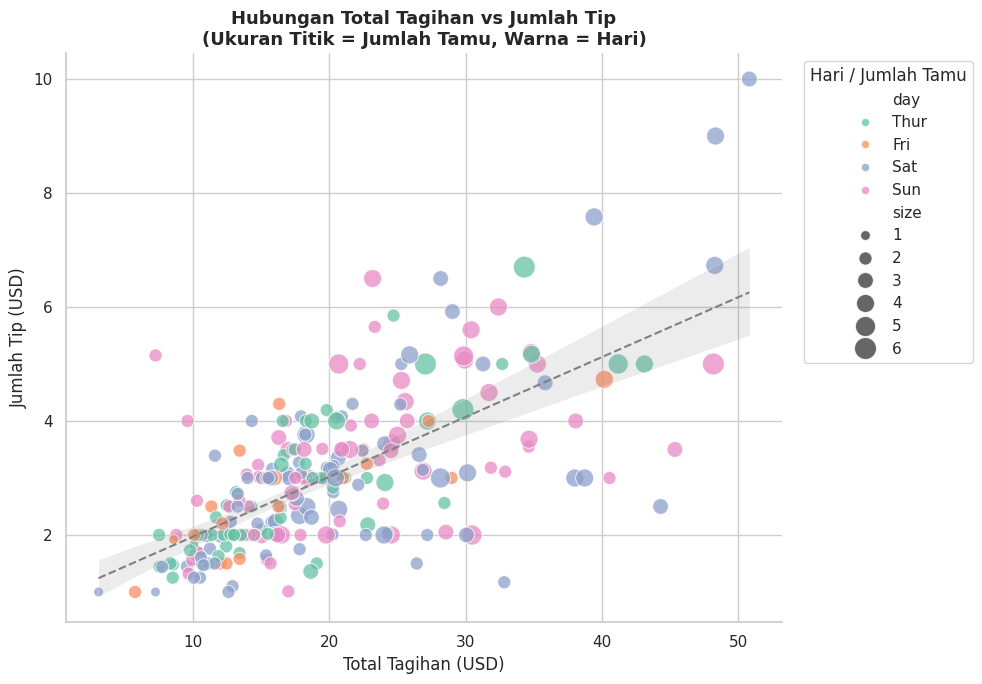

Grafik 4 tersimpan sebagai grafik4_scatter.png


In [11]:
day_order = ['Thur', 'Fri', 'Sat', 'Sun']
fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x='total_bill', y='tip',
    hue='day', hue_order=day_order,
    size='size', sizes=(50, 250),
    palette='Set2', alpha=0.75, ax=ax
)

# Garis regresi keseluruhan
sns.regplot(
    data=df, x='total_bill', y='tip',
    scatter=False, color='gray',
    line_kws={'linestyle': '--', 'linewidth': 1.5}, ax=ax
)

ax.set_title(
    'Hubungan Total Tagihan vs Jumlah Tip\n(Ukuran Titik = Jumlah Tamu, Warna = Hari)',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Total Tagihan (USD)')
ax.set_ylabel('Jumlah Tip (USD)')
ax.legend(title='Hari / Jumlah Tamu', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('grafik4_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik 4 tersimpan sebagai grafik4_scatter.png')

## 6. Dashboard Visualisasi Statis (Gabungan 4 Grafik)

Dashboard berikut menggabungkan keempat grafik dalam satu halaman 2 x 2
menggunakan `GridSpec`. File hasil ekspor disimpan sebagai `dashboard_tips.png`.

/tmp/ipykernel_1618/3565405973.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_bill = df.groupby(['day', 'sex'])['total_bill'].mean().reset_index()


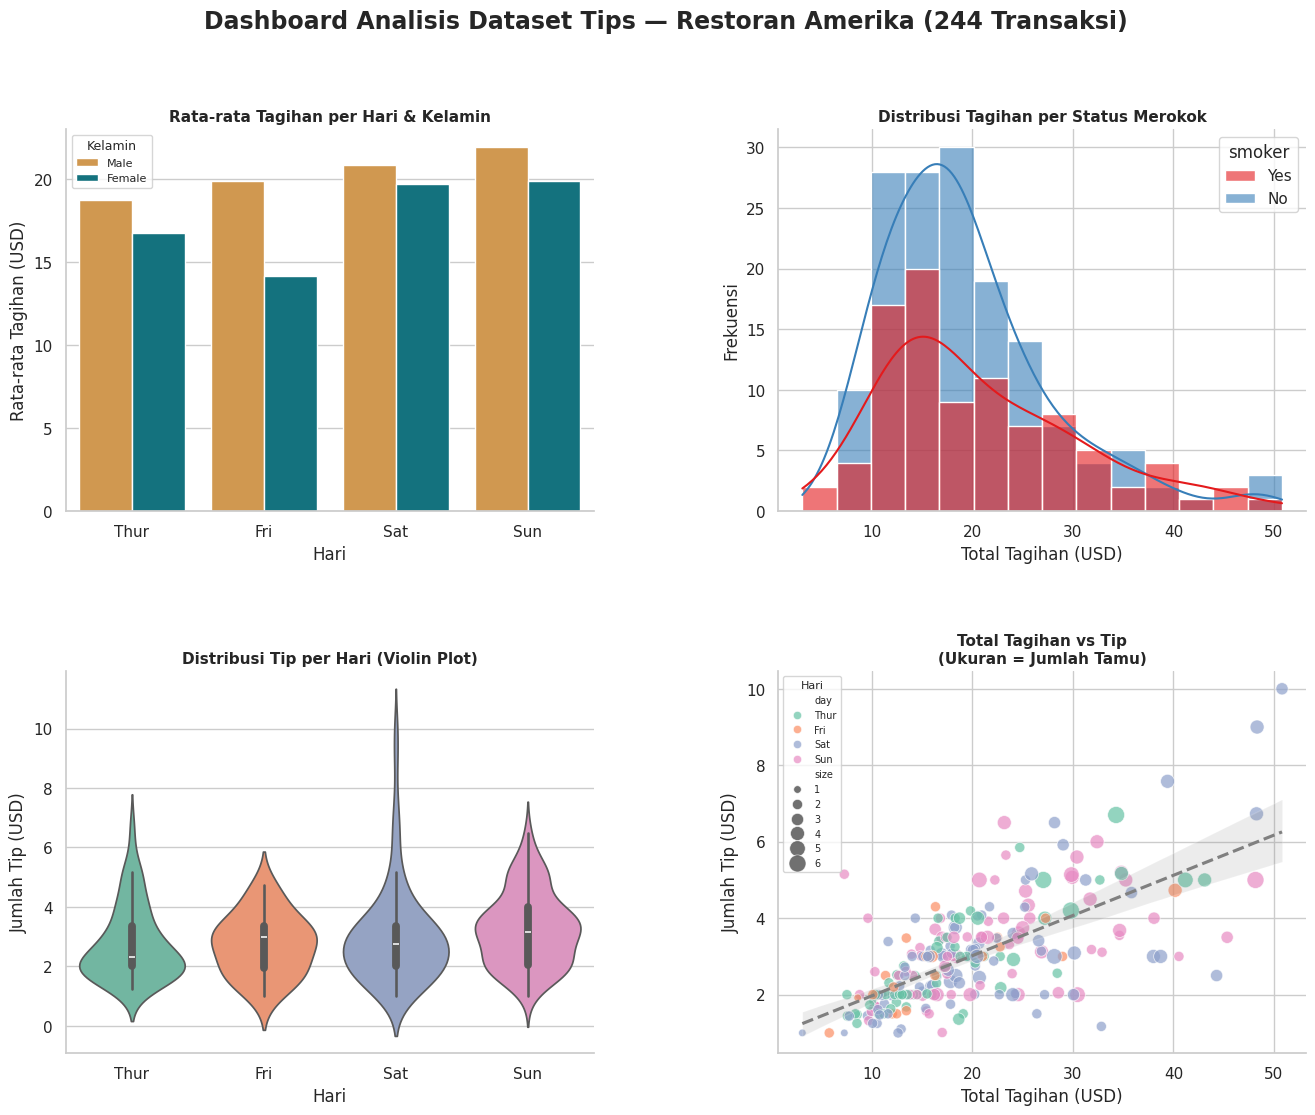

Dashboard tersimpan sebagai dashboard_tips.png


In [12]:
day_order = ['Thur', 'Fri', 'Sat', 'Sun']

fig = plt.figure(figsize=(16, 12))
fig.suptitle(
    'Dashboard Analisis Dataset Tips — Restoran Amerika (244 Transaksi)',
    fontsize=17, fontweight='bold', y=0.98
)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# ── Grafik 1: Bar Chart ────────────────────────────────────────
avg_bill = df.groupby(['day', 'sex'])['total_bill'].mean().reset_index()
sns.barplot(
    data=avg_bill, x='day', y='total_bill', hue='sex',
    order=day_order, palette=['#E69B3A', '#028090'], ax=ax1
)
ax1.set_title('Rata-rata Tagihan per Hari & Kelamin', fontsize=11, fontweight='bold')
ax1.set_xlabel('Hari')
ax1.set_ylabel('Rata-rata Tagihan (USD)')
ax1.legend(title='Kelamin', fontsize=8, title_fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)

# ── Grafik 2: Histogram + KDE ──────────────────────────────────
sns.histplot(
    data=df, x='total_bill', hue='smoker',
    kde=True, palette='Set1', alpha=0.6, ax=ax2
)
ax2.set_title('Distribusi Tagihan per Status Merokok', fontsize=11, fontweight='bold')
ax2.set_xlabel('Total Tagihan (USD)')
ax2.set_ylabel('Frekuensi')
ax2.spines[['top', 'right']].set_visible(False)

# ── Grafik 3: Violin Plot ──────────────────────────────────────
sns.violinplot(
    data=df, x='day', y='tip',
    order=day_order, hue='day', legend=False,
    inner='box', palette='Set2', ax=ax3
)
ax3.set_title('Distribusi Tip per Hari (Violin Plot)', fontsize=11, fontweight='bold')
ax3.set_xlabel('Hari')
ax3.set_ylabel('Jumlah Tip (USD)')
ax3.spines[['top', 'right']].set_visible(False)

# ── Grafik 4: Scatter Plot ─────────────────────────────────────
sns.scatterplot(
    data=df, x='total_bill', y='tip',
    hue='day', hue_order=day_order,
    size='size', sizes=(30, 150),
    palette='Set2', alpha=0.7, ax=ax4
)
sns.regplot(
    data=df, x='total_bill', y='tip',
    scatter=False, color='gray',
    line_kws={'linestyle': '--'}, ax=ax4
)
ax4.set_title(
    'Total Tagihan vs Tip\n(Ukuran = Jumlah Tamu)',
    fontsize=11, fontweight='bold'
)
ax4.set_xlabel('Total Tagihan (USD)')
ax4.set_ylabel('Jumlah Tip (USD)')
ax4.legend(title='Hari', fontsize=7, title_fontsize=8)
ax4.spines[['top', 'right']].set_visible(False)

# ── Ekspor ─────────────────────────────────────────────────────
plt.savefig('dashboard_tips.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard tersimpan sebagai dashboard_tips.png')